In [2]:
# from mobile_sam import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
from mobile_sam import SamAutomaticMaskGenerator
import torch
import cv2

c:\Users\91886\miniconda3\envs\awq\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\91886\miniconda3\envs\awq\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\91886\miniconda3\envs\awq\lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
c:\Users\91886\miniconda3\envs\awq\lib\site-packages\mobile_sam\modeling\tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.

In [3]:
from mobile_sam import sam_model_registry

In [4]:
model_type = "vit_t"
sam_checkpoint = r"D:\courses-2025\prototype\SegInference\weights\mobile_sam.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

mobile_sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
mobile_sam.to(device=device)
mobile_sam.eval()

cuda


c:\Users\91886\miniconda3\envs\awq\lib\site-packages\mobile_sam\build_sam.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Sam(
  (image_encoder): TinyViT(
    (patch_embed): PatchEmbed(
      (seq): Sequential(
        (0): Conv2d_BN(
          (c): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): GELU(approximate='none')
        (2): Conv2d_BN(
          (c): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
    )
    (layers): ModuleList(
      (0): ConvLayer(
        (blocks): ModuleList(
          (0-1): 2 x MBConv(
            (conv1): Conv2d_BN(
              (c): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (act1): GELU(approximate='none')
            (conv2): Conv2d_BN(
 

In [5]:
mask_generator = SamAutomaticMaskGenerator(mobile_sam)

In [6]:
img = cv2.imread(r'D:\courses-2025\prototype\prototypeApp\uploads\28f55df0-be33-48f9-bf20-08a8ca242b69.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [7]:
masks = mask_generator.generate(img)

In [8]:
masks

[{'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]),
  'area': 51335,
  'bbox': [200, 35, 371, 275],
  'predicted_iou': 1.054661512374878,
  'point_coords': [[359.859375, 180.0]],
  'stability_score': 0.9761285781860352,
  'crop_box': [0, 0, 853, 1280]},
 {'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [ True,  True,  True, ...,  True, False, False],
         [ True,  True,  True, ...,  True, False, False],
         [ True,  True,  True, ...,  True, False, False]]),
  'area': 711910,
  'bbox': [0, 36, 85

In [9]:
import matplotlib.pyplot as plt

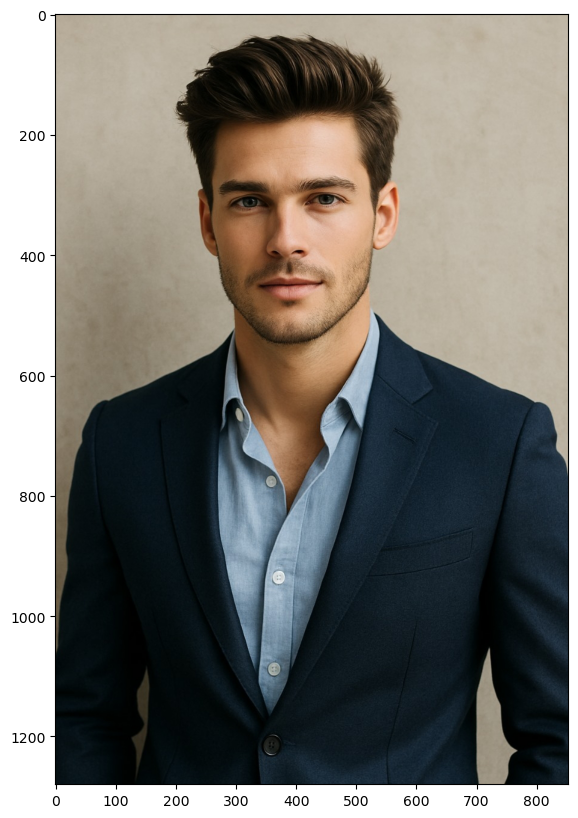

In [10]:
# image = cv2.imread('images/picture2.jpg')
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('on')
plt.show()

In [11]:
def show_mask(mask, ax):
    color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-3:-1] #mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))  

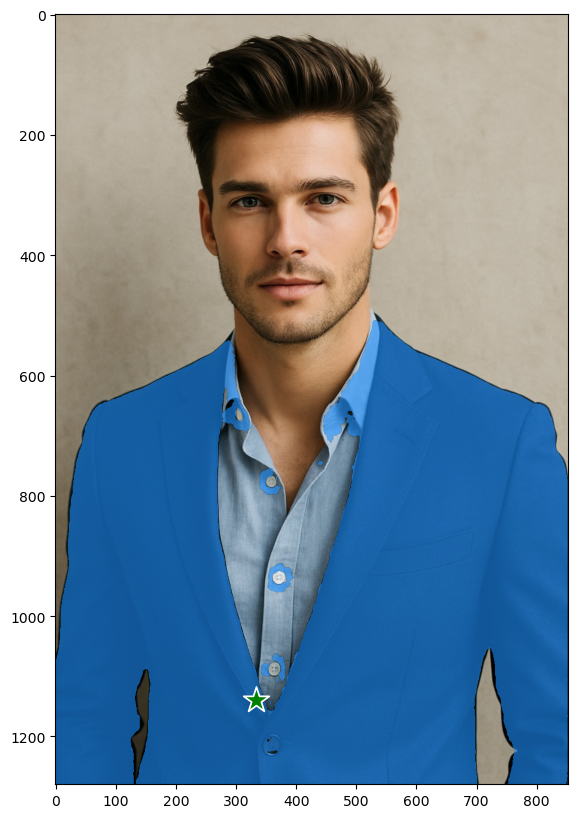

In [17]:
import numpy as np
masks_ = np.array(masks[2]['segmentation'])
#masks_ = np.array([masks_,masks_,masks_]).reshape(1280,853,3)
masks_ = masks_.reshape(1280,853,1)

plt.figure(figsize=(10,10))
plt.imshow(img)
show_mask(masks_, plt.gca())
show_points(np.array(masks[2]['point_coords']), np.array([1]), plt.gca())
plt.axis('on')
plt.show()

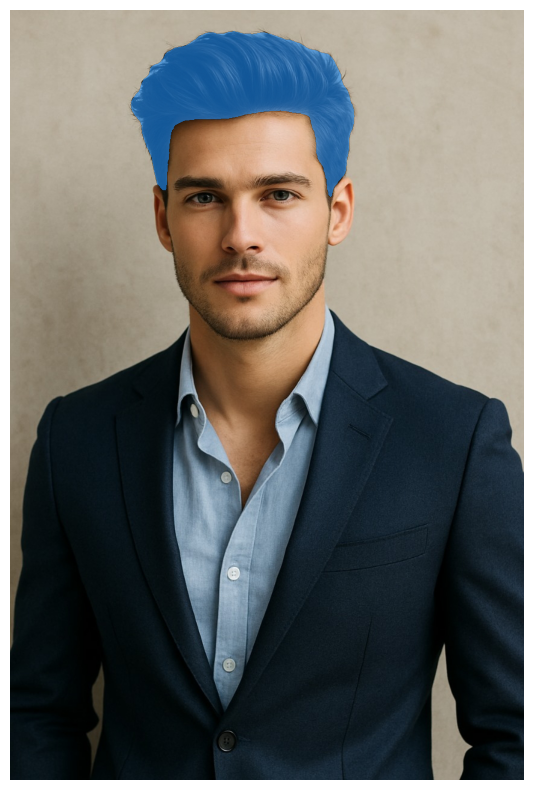

In [48]:
import numpy as np
masks_ = np.array(masks[0]['segmentation'])
#masks_ = np.array([masks_,masks_,masks_]).reshape(1280,853,3)
masks_ = masks_.reshape(1280,853,1)

plt.figure(figsize=(10,10))
plt.imshow(img)
show_mask(masks_, plt.gca())
#show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()